# Testing POT
When using POT for Hi-C data, the OT value seems to not make much sense, not being symmetrical and fluctuating very little. Thus, here we will be running multiple examples from the POT documentation, and editing the data to see how that affects the OT value.

## 1D OT

### More variance between distributions

In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
from ot.datasets import make_1D_gauss as gauss
from ot.plot import plot2D_samples_mat
import matplotlib.pyplot as plt

In [ ]:
### Generating data ###
n = 100  # nb bins
n_target = 20  # nb target distributions


    # bin positions
x = np.arange(n, dtype=np.float64)

lst_m = np.linspace(20, 90, n_target)

    # Gaussian distributions
a = gauss(n, m=20, s=5)  # m= mean, s= std

B = np.zeros((n, n_target))

for i, m in enumerate(lst_m):
    B[:, i] = gauss(n, m=m, s=5)

    # loss matrix and normalization
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)), "euclidean")
M /= M.max() * 0.1
M2 = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)), "sqeuclidean")
M2 /= M2.max() * 0.1

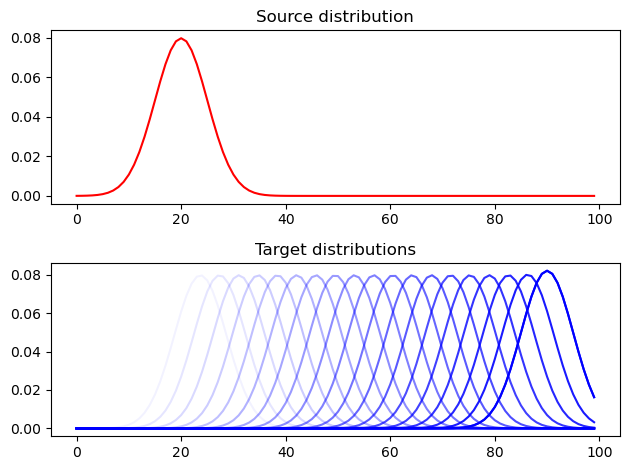

In [ ]:
### Plotting data ###
pl.figure(1)
pl.subplot(2, 1, 1)
pl.plot(x, a, "r", label="Source distribution")
pl.title("Source distribution")
pl.subplot(2, 1, 2)
for i in range(n_target):
    pl.plot(x, B[:, i], "b", alpha=i / n_target)
pl.plot(x, B[:, -1], "b", label="Target distributions")
pl.title("Target distributions")
pl.tight_layout()

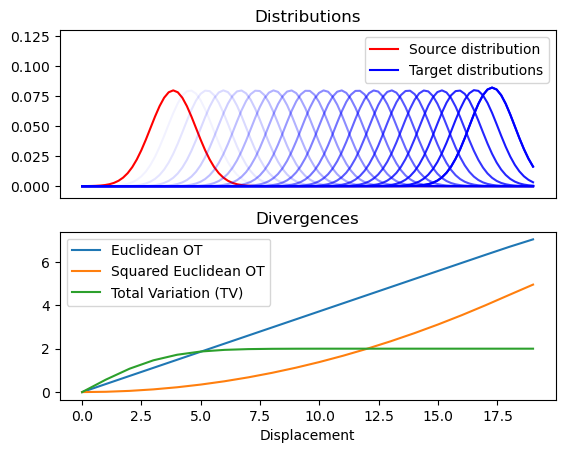

In [ ]:
### Computing EMD for all source --> target ###
d_emd = ot.emd2(a, B, M)  # direct computation of OT loss
d_emd2 = ot.emd2(a, B, M2)  # direct computation of OT loss (aka value) with metric M2
d_tv = [np.sum(abs(a - B[:, i])) for i in range(n_target)]

pl.figure(2)
pl.subplot(2, 1, 1)
pl.plot(x, a, "r", label="Source distribution")
pl.title("Distributions")
for i in range(n_target):
    pl.plot(x, B[:, i], "b", alpha=i / n_target)
pl.plot(x, B[:, -1], "b", label="Target distributions")
pl.ylim((-0.01, 0.13))
pl.xticks(())
pl.legend()
pl.subplot(2, 1, 2)
pl.plot(d_emd, label="Euclidean OT")
pl.plot(d_emd2, label="Squared Euclidean OT")
pl.plot(d_tv, label="Total Variation (TV)")
# pl.xlim((-7,23))
pl.xlabel("Displacement")
pl.title("Divergences")
pl.legend()

It seems that indeed, the OT loss (which is the same as the OT value) increases with increase distance between the distributions. Of note is also that if target = source, the value should be 0.

### Inverting source and target

In [ ]:
### Inverting source and target distributions ###
# Initialize empty list
d_emd = []
d_emd_inv = []

# Loop through all distributions
for i in range(n_target):
    b = np.ascontiguousarray(B[:, i])
    d_emd.append(round(ot.emd2(a, b, M), 8))
    d_emd_inv.append(round(ot.emd2(b, a, M), 8))

print(d_emd)
print(d_emd_inv)

print('Does inversion give the same results:', d_emd == d_emd_inv)

[0.0, 0.37210018, 0.74424108, 1.11638352, 1.488526, 1.86066848, 2.23281095, 2.60495343, 2.97709591, 3.34923839, 3.72138086, 4.09352334, 4.46566582, 4.8378083, 5.20995074, 5.58209172, 5.95419368, 6.3257093, 6.69232757, 7.03670013]
[0.0, 0.37210018, 0.74424108, 1.11638352, 1.488526, 1.86066848, 2.23281095, 2.60495343, 2.97709591, 3.34923839, 3.72138086, 4.09352334, 4.46566582, 4.8378083, 5.20995074, 5.58209172, 5.95419368, 6.3257093, 6.69232757, 7.03670013]
Does inversion give the same results: True


It seems that inversion gives the exact same results. This does not match what was observed for the Hi-C data with UOT, warranting investigation.

## 2D OT

### Utility for visualization

In [ ]:
### Utilities for visualization ###
# sphinx_gallery_start_ignore
style = {"markeredgecolor": "k"}


def plot_plan(P=None, title="", axis=True):
    if P is not None:
        plot2D_samples_mat(x1, x2, P)
    pl.plot(x1[:, 0], x1[:, 1], "ob", label="Source samples", **style)
    pl.plot(x2[:, 0], x2[:, 1], "or", label="Target samples", **style)
    if not axis:
        pl.axis("off")
    pl.title(title)

### Testing distinct distributions

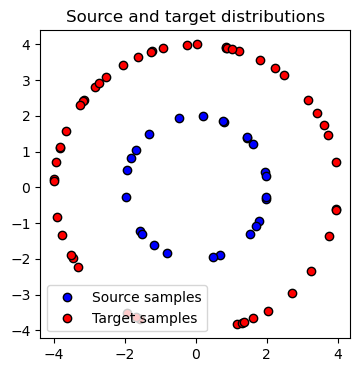

5.291880275737111

In [116]:
### Generating data ###
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # weights of points in the source domain
b = ot.utils.unif(n2)  # weights of points in the target domain

x1 = np.random.randn(n1, 2)
x1 /= np.sqrt(np.sum(x1**2, 1, keepdims=True)) / 2

x2 = np.random.randn(n2, 2)
x2 /= np.sqrt(np.sum(x2**2, 1, keepdims=True)) / 4

# Visualize data
pl.figure(1, (4, 4))
plot_plan(title="Source and target distributions")
pl.legend(loc=0)
pl.show()

# Compute the cost matrix
C = ot.dist(x1, x2)  # Squared Euclidean cost matrix by default
ot.solve_sample(x1, x2, a, b).value

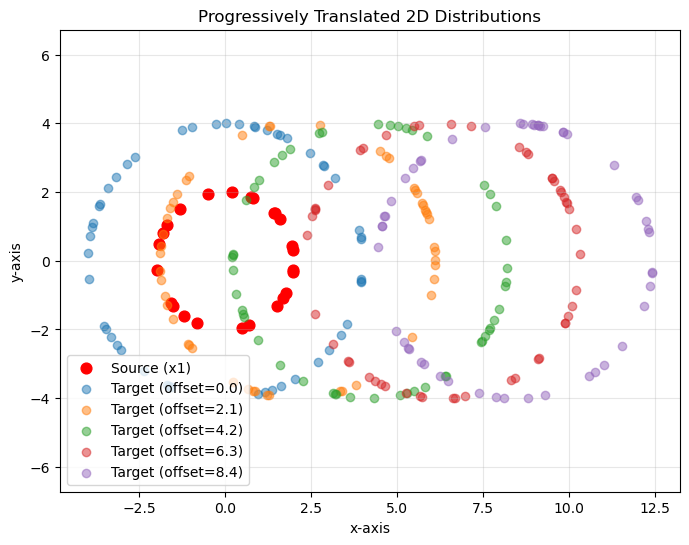

In [117]:
### Creating list of targets with centroids that are farther away ###
np.random.seed(0)

# Creating multiple different distributions
n_targets = 20
offsets = np.linspace(0.0, 10.0, n_targets)

targets = []
for offset in offsets:
    x_target = np.random.randn(n2, 2)
    x_target /= np.sqrt(np.sum(x_target**2, 1, keepdims=True)) / 4
    x_target += np.array([offset, 0])
    targets.append(x_target)

# Visualization
plt.figure(figsize=(8, 6))

    # Plot the source distribution
plt.scatter(x1[:, 0], x1[:, 1], c="red", label="Source (x1)", s=60)

    # Plot a few of the target distributions
for i, target in enumerate(targets[::4]):
    plt.scatter(target[:, 0], target[:, 1], alpha=0.5, label=f"Target (offset={offsets[i*4]:.1f})")

plt.title("Progressively Translated 2D Distributions")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

In [118]:
### Calculating OT value for differing centroid offsets ###
ot_values = []

for i in range(n_targets):
    ot_value = ot.solve_sample(x1, targets[i], a, b).value
    ot_values.append(ot_value)

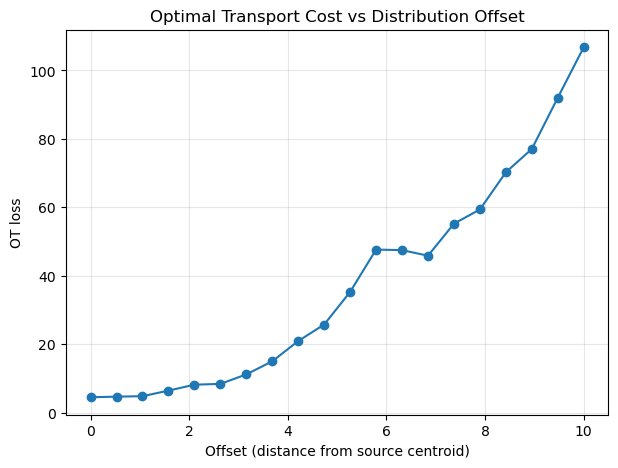

In [119]:
### Plot ###
plt.figure(figsize=(7, 5))
plt.plot(offsets, ot_values, marker='o')
plt.title("Optimal Transport Cost vs Distribution Offset")
plt.xlabel("Offset (distance from source centroid)")
plt.ylabel("OT loss")
plt.grid(True, alpha=0.3)
plt.show()

Aside from a few outliers, the OT loss generally seems to increase as the centroid is moved further away from the source distribution. Small intermediate tests once again confirmed that swapping source and target distribution did not affect the value.

## Regularized

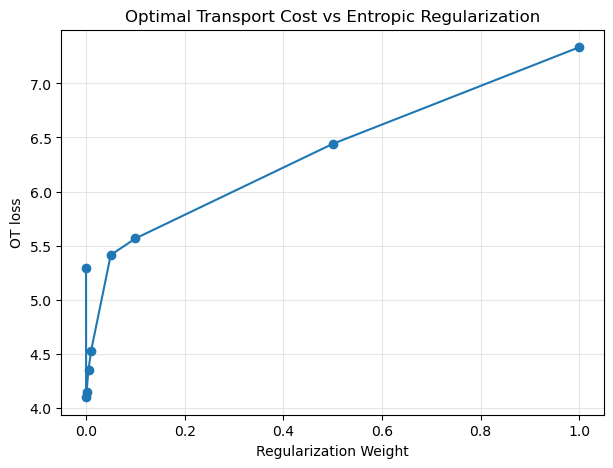

In [121]:
### Testing results for differing regularization values ###
regs = [0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
ot_values_reg = []

for reg in regs:
    ot_values_reg.append(ot.solve_sample(x1, x2, a, b, reg=reg).value)

plt.figure(figsize=(7, 5))
plt.plot(regs, ot_values_reg, marker='o')
plt.title("Optimal Transport Cost vs Entropic Regularization")
plt.xlabel("Regularization Weight")
plt.ylabel("OT loss")
plt.grid(True, alpha=0.3)
plt.show()

## Unbalanced OT

### Effects of increasing distance between datasets

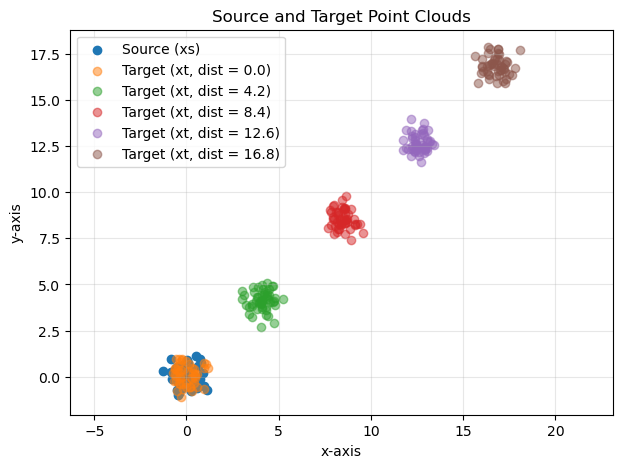

In [154]:
### Generating data ###

# Parameters for data
np.random.seed(0)
n = 50
mass_ratio = 1.5
distances = np.linspace(0, 20.0, 20)
reg_m = 5e-2

# Generating point clouds
xs = np.random.randn(n, 2) * 0.5 + np.array([0, 0])
xt_list = []

for dist in distances:
    xt = np.random.randn(n, 2) * 0.5 + np.array([dist, dist])
    xt_list.append(xt)

# Mass distributions
a = np.ones((n, )) / n 
b = np.ones((n, )) / n * mass_ratio

# Plotting data
plt.figure(figsize=(7, 5))
plt.scatter(xs[:, 0], xs[:, 1], label='Source (xs)')

for i, target in enumerate(xt_list[::4]):
    plt.scatter(target[:, 0], target[:, 1], label=f'Target (xt, dist = {distances[i*4]:.1f})', alpha=0.5)

plt.title("Source and Target Point Clouds")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

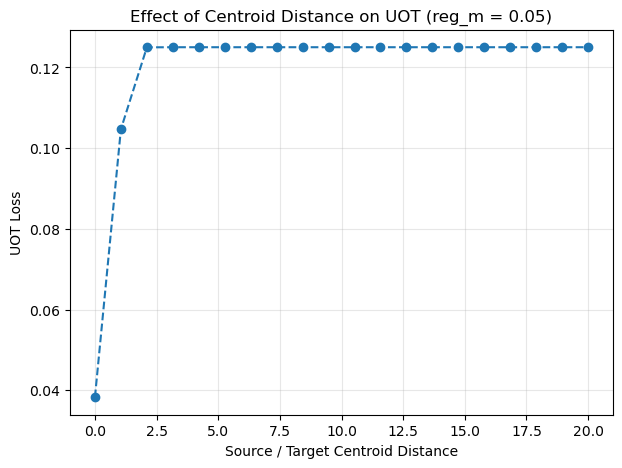

In [155]:
### Calculating UOT for farther away distributions ###
uot_values = []

for target in xt_list:
    uot_values.append(ot.solve_sample(xs, target, a, b, unbalanced=reg_m).value)

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(distances, uot_values, 'o--')
plt.xlabel("Source / Target Centroid Distance")
plt.ylabel("UOT Loss")
plt.title(f"Effect of Centroid Distance on UOT (reg_m = {reg_m})")
plt.grid(alpha=0.3)
plt.show()

It seems like the OT value is eventually saturated. From what I could find, this is due to the cost of dropping mass being lower than the cost of transporting mass. This may explain some of the values we see in the contact map example.

In [172]:
### Small check: inversion and transfer of dataset to itself ###

# Inversion
norm_uot = ot.solve_sample(xs, xt_list[0], a, b, unbalanced=reg_m).value
norm_inv = ot.solve_sample(xt_list[0], xs, b, a, unbalanced=reg_m).value
norm_uot = round(norm_uot, 8)
norm_inv = round(norm_inv, 8)
print('Does inversion give the same results:', norm_uot == norm_inv)

# Dataset to itself
uot_self = ot.solve_sample(xt_list[0], xt_list[0], b, b, unbalanced=reg_m).value
print(uot_self)
print('Does mapping a dataset to itself give a zero value:', uot_self == 0)

Does inversion give the same results: True
1.6377051977793276e-06
Does mapping a dataset to itself give a zero value: False


Inversion here gives the same result, which means there is something wrong with the UOT implementation with Hi-C data.<br>
Mapping a dataset to itself does not give a zero value. From what I can find online, this is expected behavior. Unbalanced Sinkhorn Divergence may be the go-to instead.

### Effects of differing masses

[[ 0.88202617  0.2000786 ]
 [ 0.48936899  1.1204466 ]
 [ 0.933779   -0.48863894]
 [ 0.47504421 -0.0756786 ]
 [-0.05160943  0.20529925]
 [ 0.07202179  0.72713675]
 [ 0.38051886  0.06083751]
 [ 0.22193162  0.16683716]
 [ 0.74703954 -0.10257913]
 [ 0.15653385 -0.42704787]
 [-1.27649491  0.3268093 ]
 [ 0.4322181  -0.37108251]
 [ 1.13487731 -0.72718284]
 [ 0.02287926 -0.09359193]
 [ 0.76638961  0.73467938]
 [ 0.07747371  0.18908126]
 [-0.44389287 -0.99039823]
 [-0.17395607  0.07817448]
 [ 0.61514534  0.60118992]
 [-0.19366341 -0.15115138]
 [-0.52427648 -0.71000897]
 [-0.8531351   0.9753877 ]
 [-0.25482609 -0.21903715]
 [-0.62639768  0.38874518]
 [-0.80694892 -0.10637014]
 [-0.44773328  0.19345125]
 [-0.25540257 -0.59031609]
 [-0.01409111  0.21416594]
 [ 0.03325861  0.15123595]
 [-0.31716105 -0.18137058]
 [-0.33623022 -0.17977658]
 [-0.40657314 -0.8631413 ]
 [ 0.08871307 -0.20089047]
 [-0.81509917  0.23139113]
 [-0.45364918  0.0259727 ]
 [ 0.36454528  0.06449146]
 [ 0.56970034 -0.61741291]
 

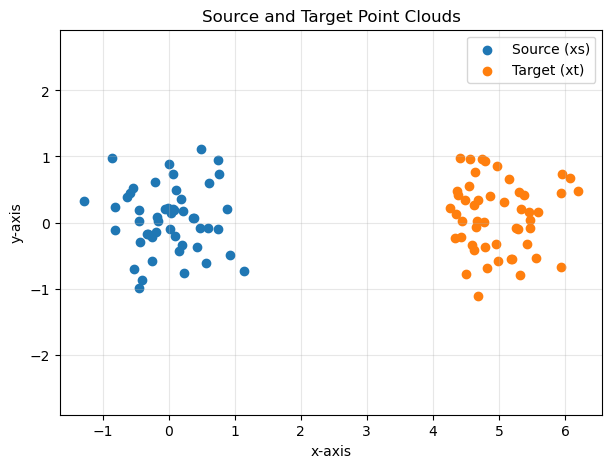

In [ ]:
### Generating data ###

# Parameters for data
np.random.seed(0)
n = 50
distance = 5.0
mass_ratios = np.linspace(0.5, 4.0, 20)
reg_m = 5e-2

# Generating point clouds
xs = np.random.randn(n, 2) * 0.5 + np.array([0, 0])
xt = np.random.randn(n, 2) * 0.5 + np.array([distance, 0])

# Source mass
a = np.ones((n, )) / n 

# Cost matrix
M = ot.dist(xs, xt)
M /= M.max()

# Plotting data
plt.figure(figsize=(7, 5))
plt.scatter(xs[:, 0], xs[:, 1], label='Source (xs)')
plt.scatter(xt[:, 0], xt[:, 1], label='Target (xt)')
plt.title("Source and Target Point Clouds")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

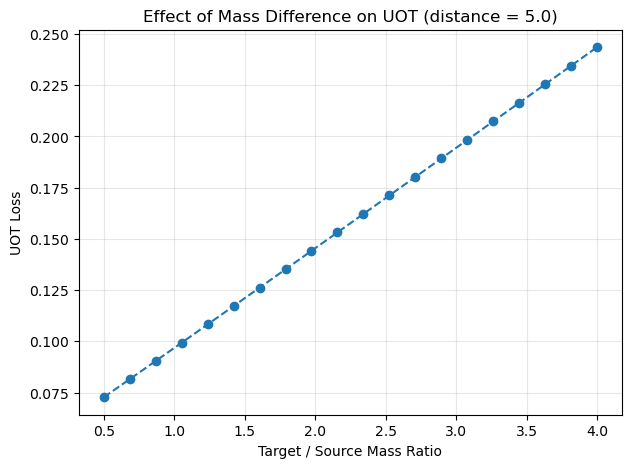

In [136]:
### Calculating UOT for different mass ratios ###

# UOT
loss = []

for ratio in mass_ratios:
    b = np.ones((n, )) / n * ratio
    unbalanced_value = ot.solve(M, a, b, unbalanced=reg_m).value
    loss.append(unbalanced_value)

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(mass_ratios, loss, 'o--')
plt.xlabel("Target / Source Mass Ratio")
plt.ylabel("UOT Loss")
plt.title(f"Effect of Mass Difference on UOT (distance = {distance})")
plt.grid(alpha=0.3)
plt.show()

It seems like OT loss for UOT increases linearly when the mass ratio between two distributions increases.

### Effects of unbalanced parameter

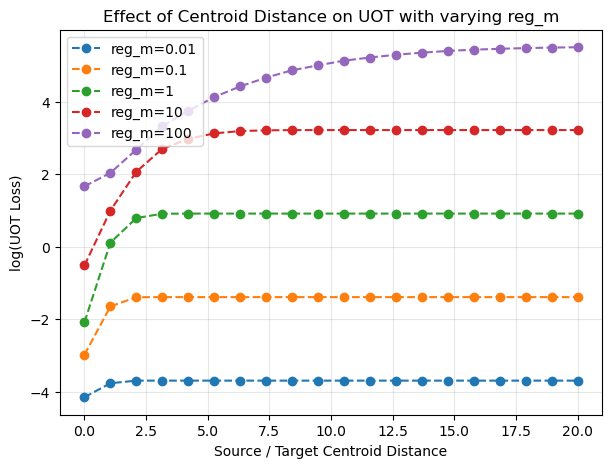

In [180]:
### With differing distances ###
    ### Generating data ###

# Parameters for data
np.random.seed(0)
n = 50
mass_ratio = 1.5
distances = np.linspace(0, 20.0, 20)
reg_m_list = [1e-2, 1e-1, 1, 10, 100]

# Generating point clouds
xs = np.random.randn(n, 2) * 0.5 + np.array([0, 0])
xt_list = []

for dist in distances:
    xt = np.random.randn(n, 2) * 0.5 + np.array([dist, dist])
    xt_list.append(xt)

# Mass distributions
a = np.ones((n, )) / n 
b = np.ones((n, )) / n * mass_ratio

    ### Calculating UOT for farther away distributions ###
uot_series = []

for reg_m in reg_m_list:
    uot_values = []

    for target in xt_list:
        uot_values.append(ot.solve_sample(xs, target, a, b, unbalanced=reg_m).value)
    
    uot_series.append(uot_values)

# Plotting
plt.figure(figsize=(7, 5))
for i, series in enumerate(uot_series):
    plt.plot(distances, np.log(series), 'o--', label=f'reg_m={reg_m_list[i]}')
plt.xlabel("Source / Target Centroid Distance")
plt.ylabel("log(UOT Loss)")
plt.legend()
plt.title(f"Effect of Centroid Distance on UOT with varying reg_m")
plt.grid(alpha=0.3)
plt.show()

Higher reg_m values delay the UOT saturation and make UOT values more comparable to exact OT

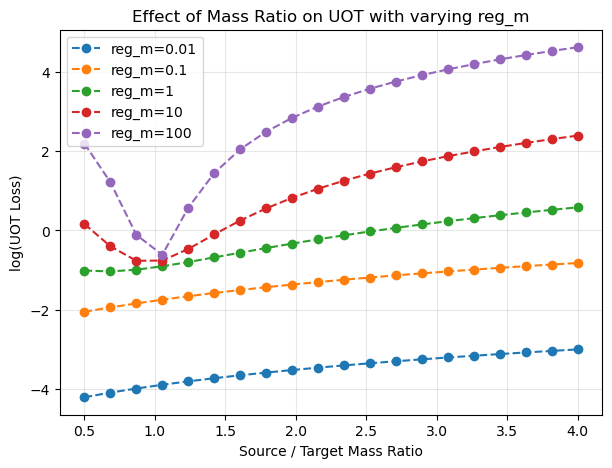

In [189]:
### With differing masses ###
    ### Generating data ###

# Parameters for data
np.random.seed(0)
n = 50
distance = 5.0
mass_ratios = np.linspace(0.5, 4.0, 20)
reg_m_list = [1e-2, 1e-1, 1, 10, 100]

# Generating point clouds
xs = np.random.randn(n, 2) * 0.5 + np.array([0, 0])
xt = np.random.randn(n, 2) * 0.5 + np.array([distance, 0])

# Source mass
a = np.ones((n, )) / n 

# Cost matrix
M = ot.dist(xs, xt)
M /= M.max()

    ### Calculating UOT for different mass ratios ###

# UOT
uot_series = []
for i, reg_m in enumerate(reg_m_list): 
    loss = []
    for ratio in mass_ratios:
        b = np.ones((n, )) / n * ratio
        unbalanced_value = ot.solve(M, a, b, unbalanced=reg_m).value
        loss.append(unbalanced_value)
    uot_series.append(loss)

# Plotting
plt.figure(figsize=(7, 5))
for i, series in enumerate(uot_series):
    plt.plot(mass_ratios, np.log(series), 'o--', label=f'reg_m={reg_m_list[i]}')
plt.xlabel("Source / Target Mass Ratio")
plt.ylabel("log(UOT Loss)")
plt.legend()
plt.title(f"Effect of Mass Ratio on UOT with varying reg_m")
plt.grid(alpha=0.3)
plt.show()